# Taking a Big Step: Large Learning Rates in Denoising Score Matching Prevent Memorization

This is the notebook that reproduces result of experiments 1 and 2.

In [ ]:
from functools import partial

import jax
import jax.flatten_util
from jax import random
from jax import numpy as jnp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from google.colab import files
import pickle
rerun: bool = False

In [ ]:
def two_layer_nn(params: tuple[jnp.array, jnp.array, jnp.array], x:jnp.array):
    w_1, w_2, b = params
    m = w_1.shape[0]
    return 1 / m * w_2 @ jax.nn.relu(w_1 @ x + b)
batch_two_layer_nn = jax.vmap(two_layer_nn, in_axes=[None, 0])

In [ ]:
def optimal_score(x, samples, sigma, mu):
    exponents = jnp.exp(jnp.sum((-(x - mu * samples) ** 2 / (2 * (sigma ** 2))), axis=1, keepdims=True))
    nominator = mu * samples * exponents
    return jnp.sum(nominator, axis=0) / jnp.sum(exponents) / (sigma ** 2) - x / (sigma ** 2)
batch_optimal_score = jax.vmap(optimal_score, in_axes=[0, None, None, None])

In [ ]:
@jax.jit
def risk_fn(params, samples, sigma, mu, key):
    noise = random.normal(key, shape = samples.shape)
    y = mu * samples + sigma * noise
    return jnp.mean((batch_two_layer_nn(params, y) + (y - mu * samples)/(sigma ** 2))**2)

grad_fn = jax.value_and_grad(risk_fn, argnums=0)

In [ ]:
def init_params(d, m, key):
    subkeys = random.split(key, 2)
    w_1 = random.normal(subkeys[0], (m, d)) / jnp.sqrt(d)
    w_2 = random.normal(subkeys[1], (d, m))
    b = jnp.zeros((m, ))
    return (w_1, w_2, b)

In [ ]:
# Toy example with dataset generated by Gaussian
def generate_dataset(d, dataset_size, deviation, key):
    subkey = random.split(key, 2)[0]
    X = deviation * random.normal(subkey, shape=(dataset_size, d))
    return X

In [ ]:
@partial(jax.jit, static_argnames=["batch_size", "m", "d"])
def sgd_step(params, full_dataset, batch_size, key, sigma, mu, master_step_size, m, d):
    subkeys = random.split(key, 2)
    batch = random.choice(subkeys[0], full_dataset, shape=(batch_size, ))
    batch_X = batch[:, :]
    risk, grad = grad_fn(params, batch_X, sigma, mu, subkeys[1])
    W_1 = params[0] - m * master_step_size * grad[0]
    w_2 = params[1] - m * master_step_size * grad[1]
    b = params[2] - m * master_step_size * grad[2]
    return (W_1, w_2, b), risk

In [ ]:
@jax.jit
def full_risk_fn(params, samples, sigma, mu):
    x = jnp.linspace(-2, 2, 500)
    y = (mu * samples + sigma * x).reshape(-1, 1)  # shape = (n_samples * 500, 1)
    x = jnp.tile(x.reshape(-1, 1), (samples.shape[0], 1)) # shape = (500 * n_samples, 1)
    return jnp.mean((batch_two_layer_nn(params, y) + x / sigma) ** 2 * jnp.exp(- x ** 2 / 2)) #

In [ ]:
def full_risk_fn_v2(params, x, sigma, mu, key, num_noise = 1000):
    dim = x.shape[0]
    z = random.normal(key, shape=(num_noise, dim))
    y = mu * x + sigma * z
    return dim * jnp.mean((batch_two_layer_nn(params, y)+z/sigma) ** 2)
batch_full_risk_fn_v2 = jax.vmap(full_risk_fn_v2, in_axes=[None, 0, None, None, None, None])

In [ ]:
@jax.jit
def full_optimal_risk(samples, sigma, mu):
    x = jnp.linspace(-5, 5, 5000)
    y = (mu * samples + sigma * x).reshape(-1, 1)
    x = jnp.tile(x.reshape(-1, 1), (samples.shape[0], 1))
    return jnp.mean((batch_optimal_score(y, samples, sigma, mu).reshape(-1, 1) + x / sigma)**2 * jnp.exp(-x**2/2))

In [ ]:
def full_optimal_risk_v2(s, samples, sigma, mu, key, num_noise=1000):
    dim = samples.shape[1]
    z = random.normal(key, shape=(num_noise, dim))
    y = mu * s + sigma * z
    return dim * jnp.mean((batch_optimal_score(y, samples, sigma, mu)+z/sigma)**2)
batch_full_optimal_risk_v2 = jax.vmap(full_optimal_risk_v2, in_axes=[0, None, None, None, None, None])

In [ ]:
def hessian_vector_product(f, primals, tangents):
    return jax.jvp(jax.grad(f), primals, tangents)[1]


@partial(jax.jit, static_argnames=["sigma", "mu",  "unravel_fn", "loss_fn"])
def param_hessian_vector_product(vec, x, sigma, mu, params, unravel_fn, loss_fn):
    delta = unravel_fn(vec)
    print(vec.shape, x.shape)
    f = lambda p: loss_fn(p, x, sigma, mu)
    return jax.flatten_util.ravel_pytree(
        hessian_vector_product(f, (params,), (delta,))
    )[0]
@partial(jax.jit, static_argnames=["sigma", "mu", "dim", "n_iter", "unravel_fn", "loss_fn"])
def largest_eigenvalue(x, sigma, mu, params, dim, key, n_iter, unravel_fn, loss_fn):
    """Returns the largest eigenvalue of the hessian of the loss, and an estimate of the error."""
    new_eigv = eigv = 1.0
    vec = random.normal(key, (dim,))
    vec = vec / jnp.linalg.norm(vec)
    keys = random.split(key, n_iter)
    for k in range(n_iter):
        eigv = new_eigv
        new_vec = param_hessian_vector_product(vec, x, sigma, mu, params, unravel_fn, loss_fn)
        new_eigv = jnp.linalg.norm(new_vec)
        vec = new_vec / new_eigv
    return eigv, jnp.abs(new_eigv - eigv)

In [ ]:
def training_loop(t, dataset_size, batch_size, step_size, m, d, n_steps, log_every, log_last=10000, deviation=1, key = None, num_noise=1000, calculate_sharpness=False):
    num_logs = n_steps//log_every
    mu = jnp.exp(-t)
    sigma = jnp.sqrt(1-jnp.exp(-2*t))
    if key is None: key = random.key(0)
    subkeys = random.split(key, 8)
    full_dataset = generate_dataset(d, dataset_size, deviation, subkeys[0])
    optimal_risk = float(jnp.mean(batch_full_optimal_risk_v2(full_dataset, full_dataset, sigma, mu, subkeys[1], num_noise)))
    params = init_params(d, m, subkeys[2])
    flat_params, unravel_fn = jax.flatten_util.ravel_pytree(params)
    dim_params = flat_params.shape[0]

    subkeys_sharpness = random.split(subkeys[3], n_steps)
    subkeys_sgd = random.split(subkeys[4], n_steps)
    subkeys_trace = random.split(subkeys[5], n_steps)
    subkeys_risk = random.split(subkeys[6], n_steps+1)
    subkeys_full_risk = random.split(subkeys[7], n_steps+1)
    logs = {
        "Step": [],
        "Train excess risk": [],
        "Full train excess risk": [],
        "sharpness": []
    }
    logs["Step"].append(0)
    train_risk = risk_fn(params, full_dataset, sigma, mu, subkeys_risk[-1])
    logs["Train excess risk"].append(float(train_risk) - optimal_risk)
    full_train_risk = jnp.mean(batch_full_risk_fn_v2(params, full_dataset, sigma, mu, subkeys_full_risk[-1], num_noise))
    logs["Full train excess risk"].append(float(full_train_risk)-optimal_risk)

    for step in tqdm(range(n_steps)):
        params, risk = sgd_step(params, full_dataset, batch_size, subkeys_sgd[step], sigma, mu, step_size, m, d)
        # flat_params, unravel_fn = jax.flatten_util.ravel_pytree(params)
        if (step + 1) % log_every == 0 and (n_steps - (step+1)) // log_every < log_last:
            logs["Step"].append(step + 1)
            logs["Train excess risk"].append(float(risk)-optimal_risk)
            full_train_risk = batch_full_risk_fn_v2(params, full_dataset, float(sigma), float(mu), subkeys_full_risk[step], num_noise)
            # print(full_train_risk)
            logs["Full train excess risk"].append(float(full_train_risk)-optimal_risk)
            if d == 1 and calculate_sharpness:
              eigv, error = largest_eigenvalue(full_dataset, float(sigma), float(mu), params, dim_params, subkeys_sharpness[step], 20, unravel_fn, full_risk_fn)
            # print(eigv, error)
              logs["sharpness"].append(eigv)
    return logs, params, full_dataset

In [ ]:
t_list = [.05, .2]
step_size_list = [.5, .1, .05, .01]
n_steps_list = [5_000, 25_000, 50_000, 200_000]

In [ ]:
def plot_function(dataset, params, exp_params, xmax=6):
    t = exp_params['t']
    deviation = exp_params.get('deviation', 1)
    sigma = jnp.sqrt(1-jnp.exp(-2 * t))
    mu = jnp.exp(-t)
    x = jnp.linspace(-xmax, xmax, 1000).reshape(-1, 1)
    y = batch_two_layer_nn(params, x)
    z = batch_optimal_score(x, dataset, sigma, mu).reshape(-1, )
    plt.plot(x, y, label = 'NN')
    plt.plot(x, -x/((deviation * mu)**2+sigma**2), label = 'identity', alpha = .5)
    plt.plot(x, z, label = 'empirical', alpha=.5)
    plt.legend()
    plt.scatter(dataset, jnp.zeros_like(dataset), marker = 'x')
    plt.show()

# Results on 1d
We plot the learnt score function and we report the observation of the loss decay as the learning rate goes smaller.

In [ ]:
res_list_plot_function = []
for t in t_list:
    print(f'Current t = {t}')
    res_dict = {
        't' : t,
        'dataset': None,
        'step_size': [],
        'params': []
    }
    for step_size, n_steps in zip(step_size_list, n_steps_list):
        print(f'Current learning rate = {step_size}')
        exp_params_1d = {
            't': t,
            'dataset_size': 20,
            'batch_size': 50,
            'step_size': step_size,
            'm': 1000,
            'd': 1,
            'n_steps': n_steps,
            'log_every': 500000,
        }
        logs, params, dataset = training_loop(**exp_params_1d)
        res_dict['dataset'] = dataset
        res_dict['step_size'].append(step_size)
        res_dict['params'].append(params)
    res_list_plot_function.append(res_dict)

with open('res_list_plot_function.pkl', 'wb') as f:
    pickle.dump(res_list_plot_function, f)
files.download('res_list_plot_function.pkl')

Current t = 0.05
Current learning rate = 0.5


100%|██████████| 5000/5000 [00:04<00:00, 1239.23it/s]


Current learning rate = 0.1


100%|██████████| 25000/25000 [00:13<00:00, 1893.82it/s]


Current learning rate = 0.05


...

100%|██████████| 50000/50000 [00:25<00:00, 1937.31it/s]


Current learning rate = 0.01


100%|██████████| 200000/200000 [01:43<00:00, 1941.64it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
with open('res_list_plot_function.pkl', 'rb') as f:
    res_list_plot_function = pickle.load(f)
with open('res_list_1d_plot_loss.pkl', 'rb') as f:
    res_list_loss_1d = pickle.load(f)
with open('res_list_10d_plot_loss.pkl', 'rb') as f:
    res_list_loss_10d = pickle.load(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

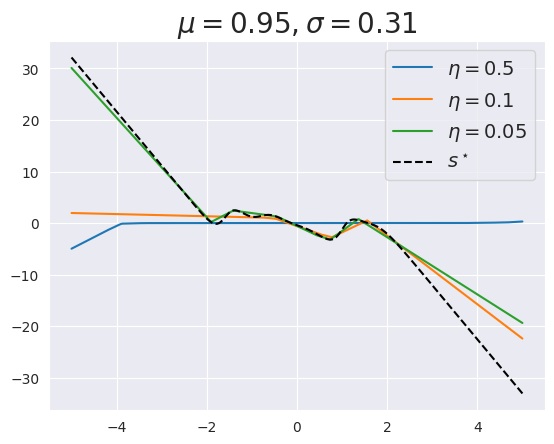

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

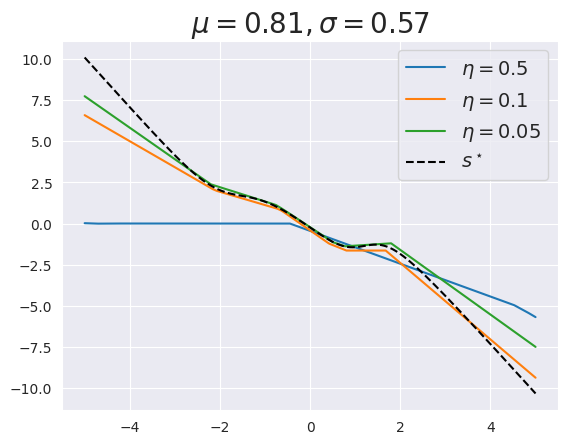

In [ ]:
xmax = 5
sns.set_style('darkgrid')
for res in res_list_plot_function:
    t = res['t']
    deviation = res.get('deviation', 1)
    sigma = jnp.sqrt(1-jnp.exp(-2 * t))
    mu = jnp.exp(-t)
    x = jnp.linspace(-xmax, xmax, 1000).reshape(-1, 1)
    for k in range(3):
        y = batch_two_layer_nn(res['params'][k], x)
        plt.plot(x, y, label = r'$\eta=$'+f'{res["step_size"][k]}')
    z = batch_optimal_score(x, res['dataset'], sigma, mu).reshape(-1, )
    # plt.plot(x, -x/((deviation * mu)**2+sigma**2), label = 'identity', alpha = .5)
    plt.plot(x, z, label = r'$s^\star$', c='black', linestyle='--')
    plt.legend(fontsize=14)
    # plt.scatter(res['dataset'], jnp.zeros_like(res['dataset']), marker = 'x')
    if t == 0.05:
        plt.title(r'$\mu=0.95, \sigma=0.31$', fontsize=20)
    if t == .2:
        plt.title(r'$ \mu=0.81, \sigma=0.57$', fontsize=20)
    plt.savefig('plot_function_t_{}.pdf'.format(t), format='pdf', bbox_inches='tight')
    files.download('plot_function_t_{}.pdf'.format(t))
    plt.show()

In [ ]:
res_list_loss_1d = []
for t in t_list:
    print(f'Current t = {t}')
    res_dict = {
        't' : t,
        'step_size': [],
        'loss': []
    }
    key = random.key(0)
    for step_size, n_steps in zip(step_size_list, n_steps_list):
        print(f'Current learning rate = {step_size}')
        n_sims = 10 if step_size==0.01 else 30
        subkeys = random.split(key, n_sims)
        for k in range(n_sims):
            exp_params_1d = {
                't': t,
                'dataset_size': 20,
                'batch_size': 50,
                'step_size': step_size,
                'm': 1000,
                'd': 1,
                'n_steps': n_steps,
                'log_every': 100,
                'num_noise': 5000,
                'key': subkeys[k],
                'log_last': 5
            }
            print(f'Round {k+1}')
            logs, params, dataset = training_loop(**exp_params_1d)
            res_dict['step_size'].append(step_size)
            # print(len(logs['Full train excess risk']))
            excess_risk = sum(logs['Full train excess risk'][-5:])/5
            print(f'{excess_risk=:.5g}')
            res_dict['loss'].append(excess_risk)
    res_list_loss_1d.append(res_dict)
with open('res_list_1d_plot_loss.pkl', 'wb') as f:
    pickle.dump(res_list_loss_1d, f)
files.download('res_list_1d_plot_loss.pkl')

Current t = 0.05
Current learning rate = 0.5
Round 1


100%|██████████| 5000/5000 [00:02<00:00, 1677.21it/s]


excess_risk=2.2678
Round 2


100%|██████████| 5000/5000 [00:03<00:00, 1650.78it/s]


excess_risk=nan
Round 3


...

excess_risk=0.027032
Round 10


100%|██████████| 200000/200000 [01:55<00:00, 1736.73it/s]

excess_risk=0.017082


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

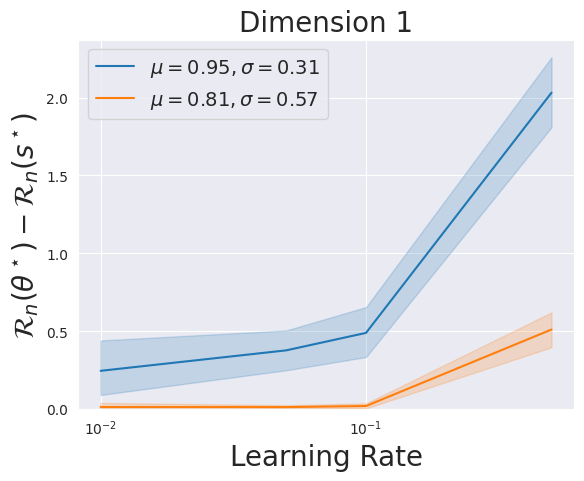

In [ ]:
labels = [r'$\mu=0.95, \sigma=0.31$', r'$ \mu=0.81, \sigma=0.57$']
for i, res in enumerate(res_list_loss_1d):
    df_res = pd.DataFrame(res)
    sns.lineplot(df_res, x = 'step_size', y = 'loss', label=labels[i])
plt.ylabel(r'$\mathcal{R}_n(\theta^\star)-\mathcal{R}_n(s^\star)$', fontsize=20)
plt.xlabel('Learning Rate', fontsize=20)
plt.ylim(0,)
plt.xscale('log')
plt.legend(fontsize=14)
plt.title('Dimension 1', fontsize=20)
plt.savefig('plot_loss.pdf', format='pdf', bbox_inches='tight')
files.download('plot_loss.pdf')
plt.show()

# Results in higher dimension
We conduct the same experiment, but this time with data of dimension 10.

In [ ]:
res_list_loss_10d = []
for t in t_list:
    print(f'Current t = {t}')
    res_dict = {
        't' : t,
        'step_size': [],
        'loss': []
    }
    key = random.key(0)
    for step_size, n_steps in zip(step_size_list, n_steps_list):
        print(f'Current learning rate = {step_size}')
        n_sims = 10 if step_size == 0.01 else 30
        subkeys = random.split(key, n_sims)
        for k in range(n_sims):
            exp_params_1d = {
                't': t,
                'dataset_size': 20,
                'batch_size': 50,
                'step_size': step_size,
                'm': 1000,
                'd': 10,
                'n_steps': n_steps,
                'log_every': 100,
                'num_noise': 50_000,
                'key': subkeys[k],
                'log_last': 5
            }
            print(f'Round {k+1}')
            logs, params, dataset = training_loop(**exp_params_1d)
            res_dict['step_size'].append(step_size)
            # print(len(logs['Full train excess risk']))
            excess_risk = sum(logs['Full train excess risk'][-5:])/5
            print(f'{excess_risk=:.5g}')
            res_dict['loss'].append(excess_risk)
    res_list_loss_10d.append(res_dict)
with open('res_list_10d_plot_loss.pkl', 'wb') as f:
    pickle.dump(res_list_loss_10d, f)
files.download('res_list_10d_plot_loss.pkl')

Current t = 0.05
Current learning rate = 0.5
Round 1


100%|██████████| 5000/5000 [00:03<00:00, 1453.54it/s]


excess_risk=12.43
Round 2


100%|██████████| 5000/5000 [00:03<00:00, 1462.63it/s]


excess_risk=23.068
Round 3


...

excess_risk=1.4346
Round 10


100%|██████████| 200000/200000 [01:54<00:00, 1750.37it/s]

excess_risk=1.508


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

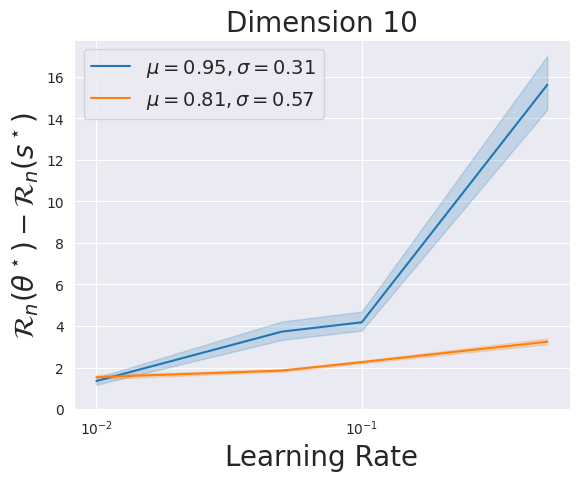

In [ ]:
for i, res in enumerate(res_list_loss_10d):
    df_res = pd.DataFrame(res)
    sns.lineplot(df_res, x = 'step_size', y = 'loss', label=labels[i])
plt.ylabel(r'$\mathcal{R}_n(\theta^\star)-\mathcal{R}_n(s^\star)$', fontsize=20)
plt.xlabel('Learning Rate', fontsize=20)
plt.ylim(0,)
plt.xscale('log')
plt.legend(fontsize=14)
plt.title('Dimension 10', fontsize=20)
plt.savefig('plot_loss_10d.pdf', format='pdf', bbox_inches='tight')
files.download('plot_loss_10d.pdf')
plt.show()

# Experiment on sharpness
We conduct experiment on the effect of learning rate to sharpness as suggested by the reviewers.

In [ ]:
t_list = [0.2]
step_size_list = .5 * (10 ** jnp.linspace(0, -1, 11))
step_size_list

In [ ]:
res_list_plot_function = []
for t in t_list:
    print(f'Current t = {t}')
    res_dict = {
        't' : t,
        'dataset': None,
        'step_size': [],
        'params': [],
        "sharpness": []
    }
    for step_size in step_size_list:
        print(f'Current learning rate = {step_size}')
        n_steps = int(5000 * .5 / step_size)
        print(f'Number of epochs = {n_steps}')
        exp_params_1d = {
            't': t,
            'dataset_size': 20,
            'batch_size': 50,
            'step_size': step_size,
            'm': 1000,
            'd': 1,
            'n_steps': n_steps,
            'log_every': 100,
        }
        logs, params, dataset = training_loop(**exp_params_1d)
        res_dict['dataset'] = dataset
        res_dict['step_size'].append(step_size)
        res_dict['params'].append(params)
        res_dict['sharpness'].append(logs["sharpness"])
        plt.plot(logs["sharpness"])
        plt.show()
        print('Mean sharpness:', jnp.mean(jnp.array(logs["sharpness"][-10:])))
    res_list_plot_function.append(res_dict)

# with open('res_list_plot_function.pkl', 'wb') as f:
#     pickle.dump(res_list_plot_function, f)
# files.download('res_list_plot_function.pkl')

In [ ]:
plt.plot(step_size_list, [jnp.mean(jnp.array(l[-20:])) for l in res_dict["sharpness"]])
plt.xscale('log')
plt.title(r'$ \mu=0.81, \sigma=0.57$', fontsize=20)
plt.xlabel('Learning Rate')
plt.ylabel('Mean Sharpness')
plt.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))
# plt.savefig('plot_sharpness.pdf', format='pdf', bbox_inches='tight')
# files.download('plot_sharpness.pdf'
plt.show()